In [ ]:
from google.colab import files
uploaded=files.upload()

Saving winequality-red.csv to winequality-red.csv


In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
cols = ["fixed acidity", "volatile acidity", "quality"]  # example names
df = pd.read_csv("winequality-red.csv", usecols=cols)


In [ ]:
df.sample(5)

,fixed acidity,volatile acidity,quality
754,7.8,0.480,6
1567,7.2,0.695,5
1342,7.6,0.540,6
1445,7.4,0.785,6
545,9.1,0.470,5


In [ ]:
print(df.shape)

(1599, 3)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fixed acidity     1599 non-null   float64
 1   volatile acidity  1599 non-null   float64
 2   quality           1599 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 37.6 KB


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
quality,0


In [ ]:
df.duplicated().sum()

np.int64(361)

<Axes: xlabel='fixed acidity', ylabel='Density'>

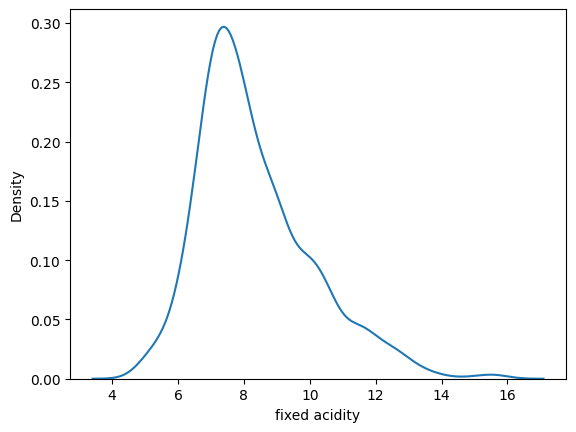

In [ ]:
#check normally or near to  distributed /.
sns.kdeplot(df['fixed acidity'])

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid'], dtype='object')

<Axes: xlabel='volatile acidity', ylabel='Density'>

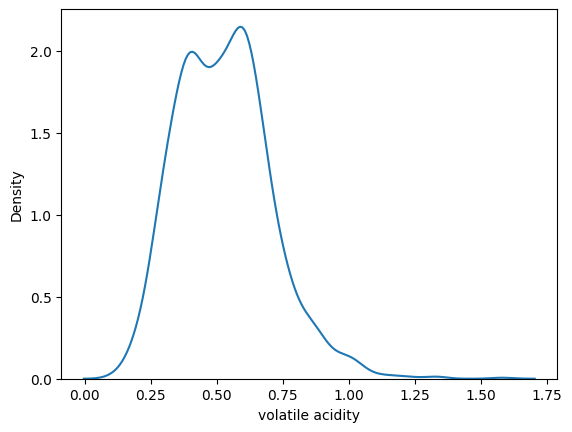

In [ ]:
sns.kdeplot(df['volatile acidity'])

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_no_scale = accuracy_score(y_test, y_pred)

print("Accuracy without scaling:", acc_no_scale)


Accuracy without scaling: 0.46875


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

model.fit(X_train_std, y_train)
y_pred = model.predict(X_test_std)

acc_std = accuracy_score(y_test, y_pred)
print("StandardScaler Accuracy:", acc_std)


StandardScaler Accuracy: 0.478125


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)

model.fit(X_train_mm, y_train)
y_pred = model.predict(X_test_mm)

acc_mm = accuracy_score(y_test, y_pred)
print("MinMaxScaler Accuracy:", acc_mm)


MinMaxScaler Accuracy: 0.465625


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_rb = scaler.fit_transform(X_train)
X_test_rb = scaler.transform(X_test)

model.fit(X_train_rb, y_train)
y_pred = model.predict(X_test_rb)

acc_rb = accuracy_score(y_test, y_pred)
print("RobustScaler Accuracy:", acc_rb)


RobustScaler Accuracy: 0.478125


In [ ]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

X_train_ma = scaler.fit_transform(X_train)
X_test_ma = scaler.transform(X_test)

model.fit(X_train_ma, y_train)
y_pred = model.predict(X_test_ma)

acc_ma = accuracy_score(y_test, y_pred)
print("MaxAbsScaler Accuracy:", acc_ma)


MaxAbsScaler Accuracy: 0.46875


In [ ]:
results = {
    "No Scaling": acc_no_scale,
    "StandardScaler": acc_std,
    "MinMaxScaler": acc_mm,
    "RobustScaler": acc_rb,
    "MaxAbsScaler": acc_ma
}

for k, v in results.items():
    print(k, ":", v)


No Scaling : 0.46875
StandardScaler : 0.478125
MinMaxScaler : 0.465625
RobustScaler : 0.478125
MaxAbsScaler : 0.46875


In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'quality'], dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # FIT + TRANSFORM
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
import numpy as np

In [ ]:
np.round(X_train.describe(), 1)

,fixed acidity,volatile acidity
count,1279.0,1279.0
mean,8.3,0.5
std,1.7,0.2
min,4.6,0.1
25%,7.1,0.4
50%,7.9,0.5
75%,9.2,0.6
max,15.9,1.6


In [ ]:
np.round(X_train_scaled.describe(), 1)

,fixed acidity,volatile acidity
count,1279.0,1279.0
mean,-0.0,0.0
std,1.0,1.0
min,-2.2,-2.3
25%,-0.7,-0.7
50%,-0.2,-0.1
75%,0.5,0.6
max,4.4,5.9


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'quality'], dtype='object')

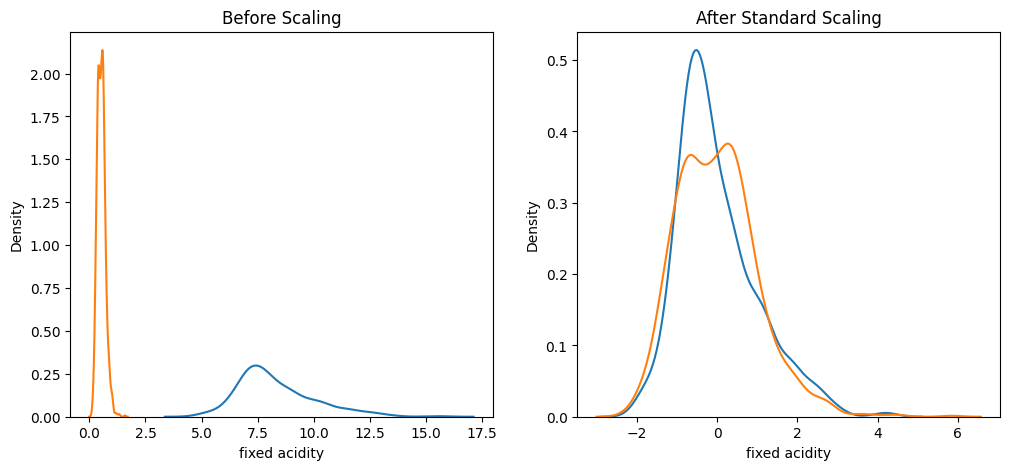

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['fixed acidity'], ax=ax1)
sns.kdeplot(X_train['volatile acidity'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['fixed acidity'], ax=ax2)
sns.kdeplot(X_train_scaled['volatile acidity'], ax=ax2)
plt.show()

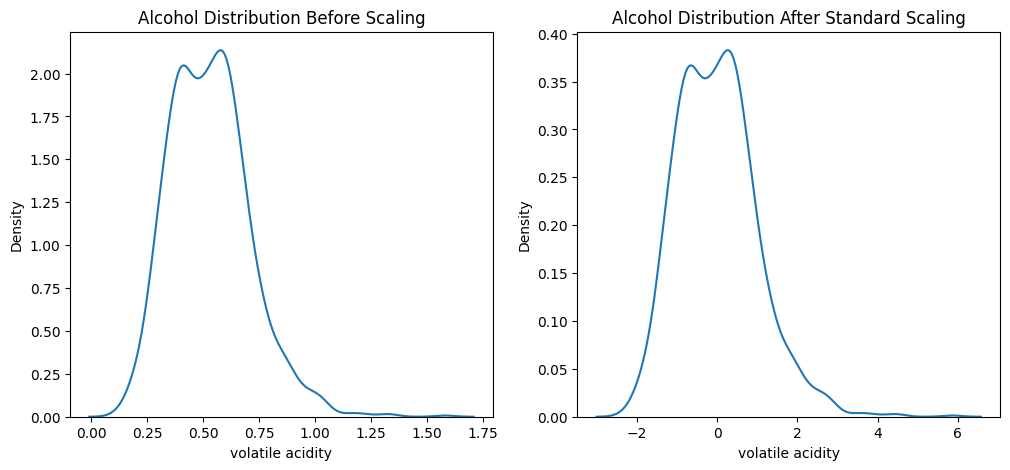

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['volatile acidity'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['volatile acidity'], ax=ax2)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)


In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
# assume X_train_mm = MinMaxScaler ka output
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_train.columns)

# ab describe chalega
X_train_mm_df.describe()

,fixed acidity,volatile acidity
count,1279.000000,1279.000000
mean,0.329530,0.281205
std,0.152588,0.122791
min,0.000000,0.000000
25%,0.221239,0.191781
50%,0.292035,0.273973
75%,0.407080,0.356164
max,1.000000,1.000000


In [ ]:
X_train_mm_df.describe().round(1)


,fixed acidity,volatile acidity
count,1279.0,1279.0
mean,0.3,0.3
std,0.2,0.1
min,0.0,0.0
25%,0.2,0.2
50%,0.3,0.3
75%,0.4,0.4
max,1.0,1.0


In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np




# 1️⃣ Initialize scaler
scaler = RobustScaler()

# 2️⃣ Fit on train
scaler.fit(X_train)

# 3️⃣ Transform train and test
X_train_robust = scaler.transform(X_train)
X_test_robust = scaler.transform(X_test)

# 4️⃣ Convert to DataFrame
X_train_robust = pd.DataFrame(X_train_robust, columns=X_train.columns)
X_test_robust = pd.DataFrame(X_test_robust, columns=X_test.columns)

# 5️⃣ Describe
print("Before scaling:\n", np.round(X_train.describe(), 1))
print("\nAfter RobustScaler:\n", np.round(X_train_robust.describe(), 1))


Before scaling:
        fixed acidity  volatile acidity
count         1279.0            1279.0
mean             8.3               0.5
std              1.7               0.2
min              4.6               0.1
25%              7.1               0.4
50%              7.9               0.5
75%              9.2               0.6
max             15.9               1.6

After RobustScaler:
        fixed acidity  volatile acidity
count         1279.0            1279.0
mean             0.2               0.0
std              0.8               0.7
min             -1.6              -1.7
25%             -0.4              -0.5
50%              0.0               0.0
75%              0.6               0.5
max              3.8               4.4


In [ ]:
from sklearn.preprocessing import MaxAbsScaler
import pandas as pd
import numpy as np

# 1️⃣ Initialize scaler
scaler = MaxAbsScaler()

# 2️⃣ Fit on train
scaler.fit(X_train)

# 3️⃣ Transform train and test
X_train_maxabs = scaler.transform(X_train)
X_test_maxabs = scaler.transform(X_test)

# 4️⃣ Convert to DataFrame
X_train_maxabs = pd.DataFrame(X_train_maxabs, columns=X_train.columns)
X_test_maxabs = pd.DataFrame(X_test_maxabs, columns=X_test.columns)

# 5️⃣ Describe
print("Before scaling:\n", np.round(X_train.describe(), 1))
print("\nAfter MaxAbsScaler:\n", np.round(X_train_maxabs.describe(), 1))



Before scaling:
        fixed acidity  volatile acidity
count         1279.0            1279.0
mean             8.3               0.5
std              1.7               0.2
min              4.6               0.1
25%              7.1               0.4
50%              7.9               0.5
75%              9.2               0.6
max             15.9               1.6

After MaxAbsScaler:
        fixed acidity  volatile acidity
count         1279.0            1279.0
mean             0.5               0.3
std              0.1               0.1
min              0.3               0.1
25%              0.4               0.3
50%              0.5               0.3
75%              0.6               0.4
max              1.0               1.0


In [ ]:
# RobustScaler → median ~0, outliers ka effect kam

# MaxAbsScaler → features scaled to -1..1 (absolute max = 1)